# 02: SDE Path Simulation and Scheme Selection

Demonstrates SDE path simulation, automatic scheme selection (Euler-Maruyama vs Milstein), and diagnostics.

In [27]:
# Setup
import sys, os
repo_root = os.path.dirname(os.getcwd())
src_path = os.path.join(repo_root, "src")
if os.path.isdir(src_path) and src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import matplotlib.pyplot as plt
from stochlib import configure_logging, get_logger
import logging

configure_logging(level=logging.INFO, verbose=True)
logger = get_logger("notebook")
logger.info("Starting SDE simulation notebook")

2026-01-19 23:58:54,656 [INFO    ] stochlib.notebook: Starting SDE simulation notebook


In [28]:
# Import SDE components
from stochlib.setup import Grid, VelocitiesConfig, DiffusionConfig
from stochlib.sde import PathSimulator, StepSchemeAdvisor, PathDiagnostics
from stochlib.sde.bridge import fp_to_sde_drift, fp_to_sde_diffusion, grid_bounds_from_grid
from stochlib.sde.plotting import plot_trajectories, plot_mean_variance, plot_phase_portrait

logger.info("Imported SDE components")

2026-01-19 23:58:55,058 [INFO    ] stochlib.notebook: Imported SDE components


In [29]:
# Helper to ensure mean/var have shape (n_times, n_dims)
def stats2d(mean, var):
    mean2 = mean if mean.ndim == 2 else mean[:, None]
    var2 = var if var.ndim == 2 else var[:, None]
    return mean2, var2

logger.info("Defined stats2d helper for plotting")

2026-01-19 23:58:55,600 [INFO    ] stochlib.notebook: Defined stats2d helper for plotting


## Part 1: Simple Brownian Motion

In [30]:
# Simple 1D Brownian motion: dX = dW
def drift_const_zero(x, t):
    """Zero drift"""
    if isinstance(x, np.ndarray):
        return np.zeros_like(x)
    return 0.0

def diffusion_const_one(x, t):
    """Constant diffusion sigma=1.0"""
    if isinstance(x, np.ndarray):
        return np.ones_like(x)
    return 1.0

# Setup simulator (auto scheme selection)
sim = PathSimulator(
    drift=drift_const_zero,
    diffusion=diffusion_const_one,
    scheme='auto',
    rng=np.random.default_rng(42)
)

logger.info("Created PathSimulator for Brownian motion")

2026-01-19 23:58:57,357 [INFO    ] stochlib.notebook: Created PathSimulator for Brownian motion


In [31]:
# Simulate paths
n_paths = 1000
t_array = np.linspace(0, 1.0, 101)  # 100 steps
x0 = np.zeros((n_paths, 1))  # Start at origin

logger.info(f"Simulating {n_paths} paths to t={t_array[-1]}")
result = sim.simulate(x0=x0, t_array=t_array, save_paths=True)

logger.info(f"Simulation complete. Keys: {result.keys()}")
print(f"Paths shape: {result['paths'].shape}")
print(f"Mean shape: {result['mean'].shape}")
print(f"Variance shape: {result['var'].shape}")

2026-01-19 23:58:58,214 [INFO    ] stochlib.notebook: Simulating 1000 paths to t=1.0
2026-01-19 23:58:58,224 [INFO    ] stochlib.notebook: Simulation complete. Keys: dict_keys(['mean', 'var', 'times', 'diagnostics', 'alive_mask', 'n_alive', 'exit_times', 'paths'])
Paths shape: (1000, 101, 1)
Mean shape: (101, 1)
Variance shape: (101, 1)


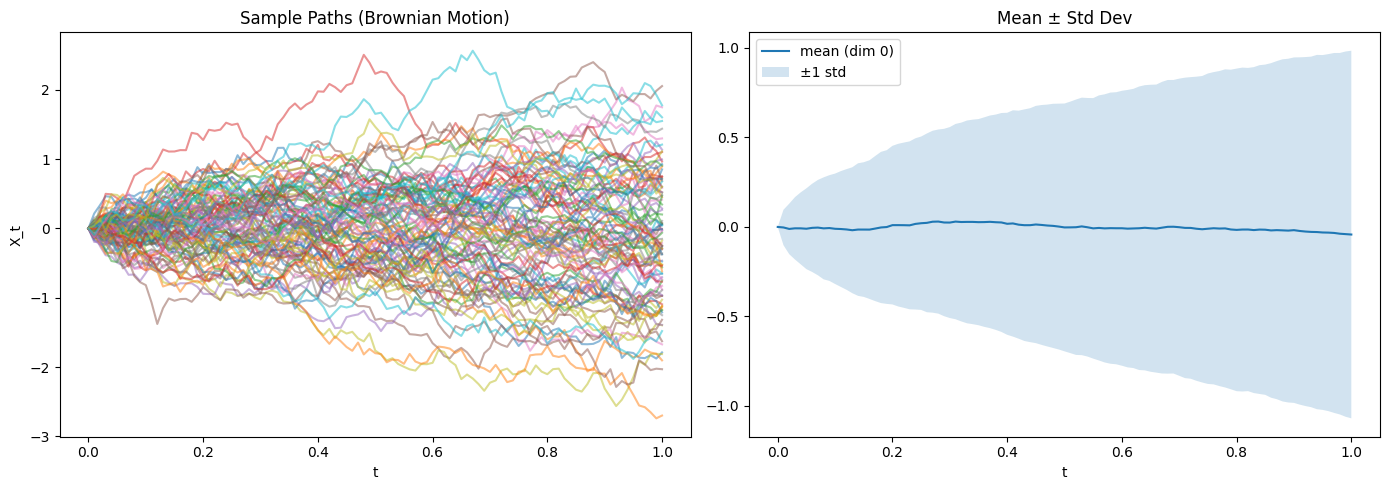

2026-01-19 23:58:59,183 [INFO    ] stochlib.notebook: Plotted trajectories


In [32]:
# Plot trajectories with mean and variance bands
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sample trajectories
plot_trajectories(result['paths'], t_array, dim=0, max_paths=100, ax=axes[0])
axes[0].set_title('Sample Paths (Brownian Motion)')

# Right: mean ± std
mean_plot, var_plot = stats2d(result['mean'], result['var'])
plot_mean_variance(t_array, mean_plot, var_plot, dim=0, ax=axes[1])
axes[1].set_title('Mean ± Std Dev')

plt.tight_layout()
plt.show()

logger.info("Plotted trajectories")

## Part 2: Advection-Diffusion (Drift + Diffusion)

In [33]:
# Advection-diffusion: dX = 0.5*X*dt + sqrt(0.2)*dW
def drift_linear(x, t):
    """Linear drift: mu = 0.5*x"""
    return 0.5 * x

def diffusion_const(x, t):
    """Constant diffusion: sigma = sqrt(0.2)"""
    if isinstance(x, np.ndarray):
        return np.full_like(x, np.sqrt(0.2))
    return np.sqrt(0.2)

def diffusion_jacobian(x, t):
    """Jacobian of diffusion (for Milstein scheme)"""
    return np.zeros_like(x)  # Constant diffusion has zero Jacobian

# Simulator
sim_ad = PathSimulator(
    drift=drift_linear,
    diffusion=diffusion_const,
    diffusion_jacobian=diffusion_jacobian,
    scheme='auto',
    rng=np.random.default_rng(43)
)

logger.info("Created advection-diffusion simulator")

2026-01-19 23:59:06,907 [INFO    ] stochlib.notebook: Created advection-diffusion simulator


In [34]:
# Simulate
x0_ad = np.ones((n_paths, 1))  # Start at x=1
result_ad = sim_ad.simulate(x0=x0_ad, t_array=t_array, save_paths=True)

logger.info("Advection-diffusion simulation complete")
print(f"Final mean: {result_ad['mean'][-1, 0]:.4f}")
print(f"Final variance: {result_ad['var'][-1, 0]:.4f}")

2026-01-19 23:59:07,797 [INFO    ] stochlib.notebook: Advection-diffusion simulation complete
Final mean: 1.6315
Final variance: 0.3282


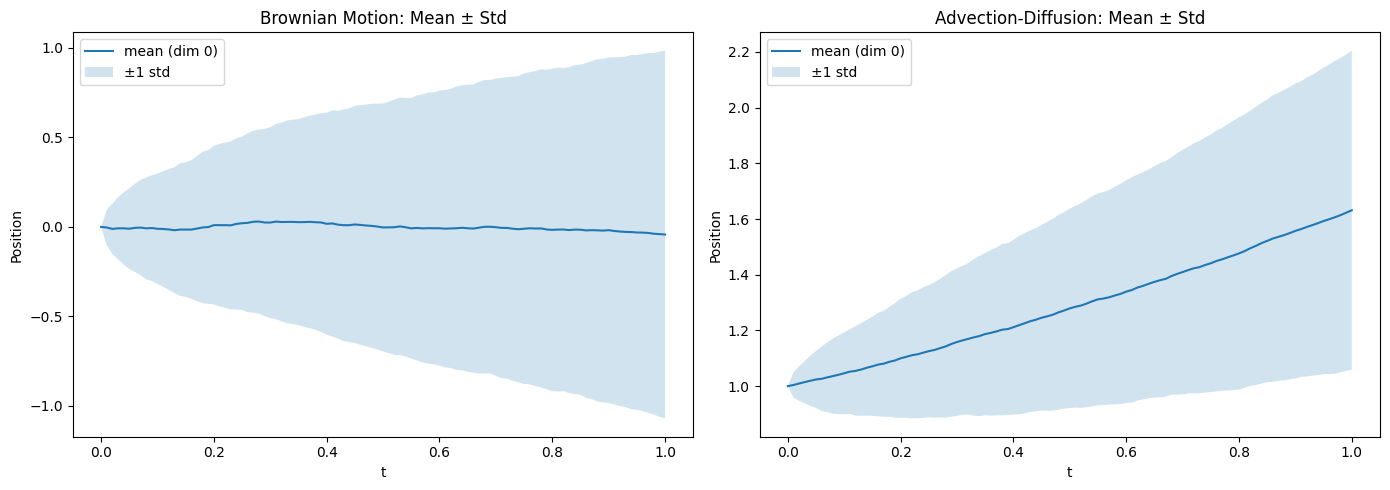

2026-01-19 23:59:08,557 [INFO    ] stochlib.notebook: Comparison plot created


In [35]:
# Compare different schemes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ensure mean/var are 2D
mean_plot, var_plot = stats2d(result['mean'], result['var'])
mean_ad_plot, var_ad_plot = stats2d(result_ad['mean'], result_ad['var'])

# Brownian motion
plot_mean_variance(t_array, mean_plot, var_plot, dim=0, ax=axes[0])
axes[0].set_title('Brownian Motion: Mean ± Std')
axes[0].set_ylabel('Position')

# Advection-diffusion
plot_mean_variance(t_array, mean_ad_plot, var_ad_plot, dim=0, ax=axes[1])
axes[1].set_title('Advection-Diffusion: Mean ± Std')
axes[1].set_ylabel('Position')

plt.tight_layout()
plt.show()

logger.info("Comparison plot created")

## Part 3: Path Diagnostics

In [ ]:
# Quick statistics from simulation outputs
mean_plot, var_plot = stats2d(result['mean'], result['var'])

final_mean = float(mean_plot[-1, 0])
final_var = float(var_plot[-1, 0])
initial_mean = float(mean_plot[0, 0])
initial_var = float(var_plot[0, 0])

logger.info("Computed summary stats from simulation outputs")

print("Brownian Motion Statistics (from stored outputs):")
print(f"  Initial mean: {initial_mean:.6f}")
print(f"  Final mean: {final_mean:.6f}")
print(f"  Initial variance: {initial_var:.6f}")
print(f"  Final variance: {final_var:.6f}")

AttributeError: 'PathDiagnostics' object has no attribute 'track'

## Summary

This notebook demonstrated:
1. Setting up drift and diffusion functions for `PathSimulator`
2. Simulating Brownian motion and advection-diffusion with auto scheme selection
3. Plotting trajectories plus mean ± std bands using library helpers
4. Reading basic summary statistics from stored simulation outputs